<a href="https://colab.research.google.com/github/Shivam250124/Machine_Learning-/blob/main/income_clustering_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3 align='center'>K Means Clustering</h3>

Problem Statement: Use K Means for customer segmentation. We will cluster people based on their income.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


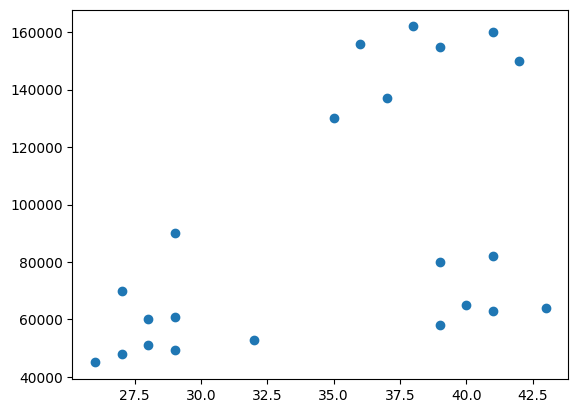

In [2]:
plt.scatter(df['Age'], df['Income($)'])
plt.show()

### K Means Clustering

In [3]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3,n_init='auto')
km.fit(df[["Age","Income($)"]])
km.labels_

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [5]:
df['Cluster']=km.labels_
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


<Axes: xlabel='Age', ylabel='Income($)'>

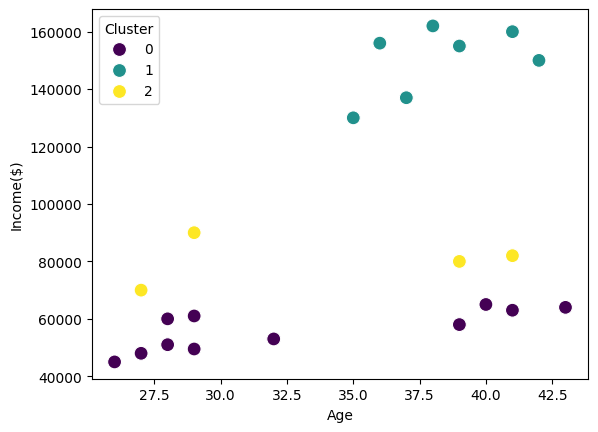

In [6]:
import seaborn as sns

sns.scatterplot(df, x='Age', y='Income($)', hue='Cluster', palette='viridis',s=100)

### Min Max Scaling

Clusters are not formed properly. It can be due to Age and Income columns being on a different scale. We can try scaling them

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled= pd.DataFrame(columns=['  Age', 'Income($)'])

df_scaled[["Age", "Income($)"]] = scaler.fit_transform(df[["Age", "Income($)"]])
df_scaled.head()

,Age,Income($),Age
0,NaN,0.213675,0.058824
1,NaN,0.384615,0.176471
2,NaN,0.136752,0.176471
3,NaN,0.128205,0.117647
4,NaN,0.897436,0.941176


In [15]:
km = KMeans(n_clusters=3, n_init='auto')
km.fit(df_scaled[["Age", "Income($)"]])
df_scaled['Cluster'] = km.labels_
df_scaled.head()

,Age,Income($),Age,Cluster
0,NaN,0.213675,0.058824,1
1,NaN,0.384615,0.176471,1
2,NaN,0.136752,0.176471,1
3,NaN,0.128205,0.117647,1
4,NaN,0.897436,0.941176,0


In [9]:
km.inertia_# sum of squared error

0.4750783498553097

In [12]:
centroids = km.cluster_centers_
centroids

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

<Axes: xlabel='Age', ylabel='Income($)'>

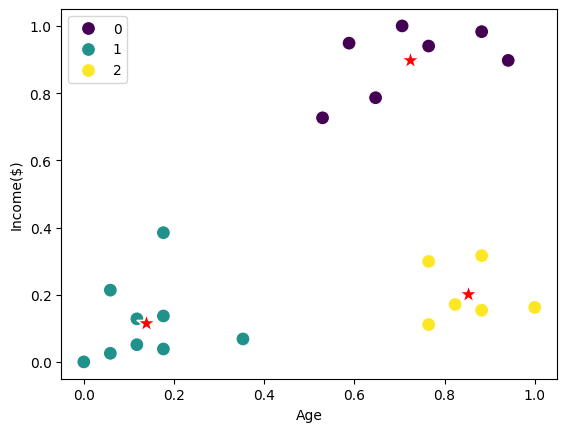

In [16]:

sns.scatterplot(df_scaled, x='Age', y='Income($)',  palette='viridis', s=100, hue="Cluster")
sns.scatterplot(x=centroids[:,0], y=centroids[:,1],  s=200, color="red", marker='*')

### Elbow method to determine optimal number of clusters

In [17]:
sse =[]

k_rng=range(1,10)

for k in k_rng:
  km=KMeans(n_clusters=k,n_init='auto')
  km.fit(df_scaled[["Age","Income($)"]])
  sse.append(km.inertia_)# sum of squared error

sse

[5.434011511988179,
 2.3456144914725936,
 0.4750783498553097,
 0.3687734076440591,
 0.27768187154369994,
 0.2671557284269111,
 0.19879303594775452,
 0.15205897076959982,
 0.11934883100559024]

In [ ]:
sse = []

k_rng = range(1,10)

for k in k_rng:
    km = KMeans(n_clusters=k, n_init='auto')
    km.fit(df_scaled[["Age", "Income($)"]])
    sse.append(km.inertia_)
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.38815291664787444,
 0.3115461388117863,
 0.22624835214667535,
 0.18275153026579996,
 0.13265419827245162,
 0.12618389852922432]

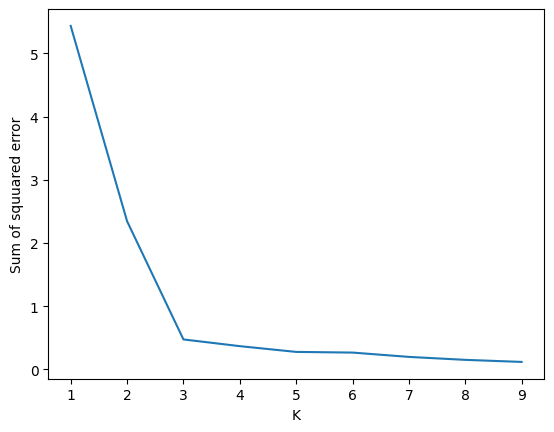

In [18]:
plt.xlabel('K')
plt.ylabel('Sum of squuared error')
plt.plot(k_rng,sse)
plt.show()

The chart shows optimal number of clusters are 3